In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
FILENAME = "data/boston_buildings.csv"
LABEL = "use_class"
BOOLS = ["historic_district", "landmark", "flood", "stormwater"]
QUANT = ["yr_built", "sqft", "ct_perc_children_under_5", "ct_perc_over_65"]
FEATURES = [*BOOLS, *QUANT]
ALL = [LABEL, *BOOLS, *QUANT]

In [3]:
df = pd.read_csv(FILENAME)
df[BOOLS] = df[BOOLS].replace({"f": 0, "t": 1})
scaler = MinMaxScaler()
df[FEATURES] = scaler.fit_transform(df[FEATURES])
df = df[ALL].dropna()
df

/var/folders/k8/3s73cc5x32b13wxlg0_xqlk80000gn/T/ipykernel_83357/347748891.py:1: DtypeWarning: Columns (1,40,44,47,51,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILENAME)
/var/folders/k8/3s73cc5x32b13wxlg0_xqlk80000gn/T/ipykernel_83357/347748891.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[BOOLS] = df[BOOLS].replace({"f": 0, "t": 1})


,use_class,historic_district,landmark,flood,stormwater,yr_built,sqft,ct_perc_children_under_5,ct_perc_over_65
1,Residential,0.0,0.0,0.0,0.0,0.752351,0.000671,0.513849,0.137188
2,Residential,0.0,0.0,1.0,1.0,0.548589,0.000680,0.533572,0.253383
31,Residential,0.0,0.0,0.0,0.0,0.517241,0.000804,0.250921,0.195438
38,Commercial,0.0,0.0,0.0,0.0,0.752351,0.002697,0.750853,0.113714
112,Residential,0.0,1.0,0.0,0.0,0.940439,0.117429,0.193456,0.206371
...,...,...,...,...,...,...,...,...,...
98924,Residential,0.0,0.0,0.0,0.0,0.962382,0.000943,0.569840,0.176081
98925,Residential,0.0,0.0,0.0,0.0,0.940439,0.001589,0.265891,0.223662
98926,Residential,0.0,0.0,0.0,0.0,0.956113,0.001321,0.471880,0.264900
98927,Residential,0.0,0.0,0.0,0.0,0.981191,0.001077,0.250921,0.195438


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES], df[LABEL], test_size=0.2
    )

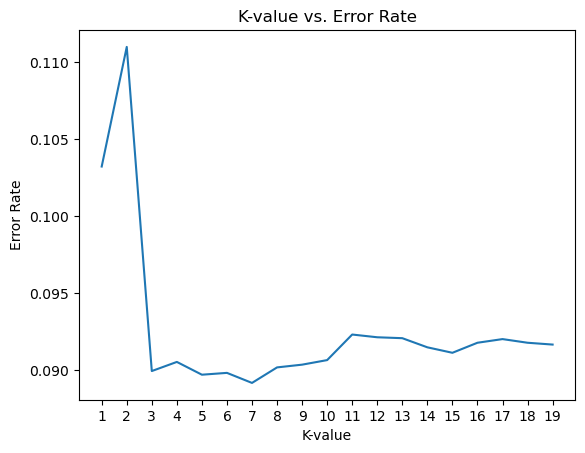

In [5]:
error_rates = []

for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    accuracy = knn.score(X_test, y_test)
    error_rates.append(1 - accuracy)

plt.title("K-value vs. Error Rate")
plt.xlabel("K-value")
plt.ylabel("Error Rate")
plt.plot(range(1, 20), error_rates)
plt.xticks(range(1, 20))
plt.show()

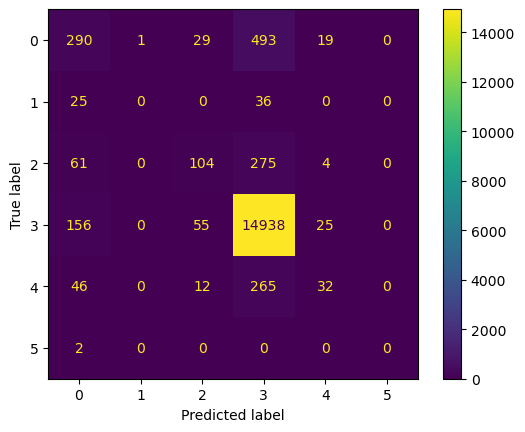

In [14]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
predicted = knn.predict(X_test)
cm = metrics.confusion_matrix(y_test, predicted)
display = metrics.ConfusionMatrixDisplay(cm)
display.plot()
